## 1. Setup

### 1.0 Google Drive Sync
Pode ignorar essa seção se não estiver usando Google Colab

In [ ]:
# Adicionar o conteúdo do drive no caminho do sistema

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# modificar para o diretorio que contem a pasta do repositorio ao rodar esse notebook
# fazemos isso para ele conseguir ler a pasta /datasets que precisa estar dentro do diretório que contem esse notebook
%cd /content/drive/MyDrive/projetos-if702/projeto-churn/

!ls

/content/drive/Othercomputers/My Computer/projeto-churn
0_preprocessamento.ipynb  2_XGBoost.ipynb	  datasets     __pycache__
1_MLP.ipynb		  churn_preprocessing.py  ml_utils.py  split_churn.py


In [ ]:
import sys

# Colocar o caminho exato da pasta onde está a pasta referente ao repositório do projeto
# O caminho base é sempre '/content/drive/MyDrive/' se criar um atalho no "Meu Drive" para a pasta sincronizada
caminho_projeto = '/content/drive/MyDrive/projetos-if702/projeto-churn'

# Adiciona a pasta no path do Python, caso ainda não esteja lá
if caminho_projeto not in sys.path:
    sys.path.append(caminho_projeto)

In [ ]:

# Fazer recarregamento dos modulos locais.
# Assim não precisa reiniciar o kernel do colab toda vez que modificar alguma coisa nos arquivos .py

import importlib
sys.modules['imp'] = importlib

%load_ext autoreload
%autoreload 2

### 1.1 Importar Libs

In [13]:
from pathlib import Path
import os
import sys

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from scikitplot.metrics import plot_ks_statistic
import autogluon.tabular
from autogluon.tabular import TabularDataset, TabularPredictor
from joblib import dump, load

from churn_preprocessing import load_split_datasets, OUTPUT_PREFIX, TARGET_COL
from ml_utils import (
    ks_test, predict_scores, compute_metrics, 
    train_model, evaluate_model,
    build_hyperparameter_space, print_hyperparameter_space,
    plot_confusion_matrix, plot_roc_curve,
    get_loss_fn,
    DEFAULT_SCORING_METRIC, AVAILABLE_METRICS_SEARCH, AVAILABLE_LOSSES,
    RANDOM_STATE_MODEL, RANDOM_STATE_SAMPLE,
    )

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style('whitegrid')

print("Bibliotecas importadas com sucesso")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Autogluon: {autogluon.tabular.__version__}")
print(f"PyTorch: {torch.__version__}")

## CPU ou GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device.type.upper())


Bibliotecas importadas com sucesso
Pandas: 2.3.3
NumPy: 2.3.5
Autogluon: 1.5.0
PyTorch: 2.6.0+cu124
Device: CUDA


In [ ]:

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "datasets").exists() and (PROJECT_DIR / "projeto-churn").exists():
    PROJECT_DIR = PROJECT_DIR / "projeto-churn"

os.chdir(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / "datasets"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
SEARCH_DIR = PROJECT_DIR / "searches"
PREDICTOR_PATH = MODELS_DIR / "mitra_autogluon"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

print(f"Projeto em: {PROJECT_DIR.resolve()}")
print(f"Dataset dir: {DATA_DIR.resolve()}")
print(f"Models dir: {MODELS_DIR.resolve()}")
print(f"Predictor path: {PREDICTOR_PATH.resolve()}")
print(f"Results dir: {RESULTS_DIR.resolve()}")

### 1.2 Configuração do Modelo

In [ ]:


MODEL_NAME = 'Mitra'
MODEL_CLASS = TabularPredictor
module_name = getattr(MODEL_CLASS, "__module__", "")
print(f"Modelo configurado: {MODEL_NAME}")
print(module_name)


Modelo configurado: Mitra
autogluon.tabular.predictor.predictor


## 2. Carregamento dos Dados

In [6]:
print('=== CARREGAMENTO DOS DATASETS PRÉ-PROCESSADOS ===')

train_data, val_data, test_data = load_split_datasets(prefix=OUTPUT_PREFIX)

train_ag = TabularDataset(train_data.copy())
val_ag = TabularDataset(val_data.copy())
test_ag = TabularDataset(test_data.copy())

print(f'Treino: {train_data.shape}')
print(f'Validação: {val_data.shape}')
print(f'Teste: {test_data.shape}')
print(f'Coluna alvo: {TARGET_COL}')
print(f'Features: {train_data.shape[1] - 1}')

print('\nDistribuição das classes:')
print('Treino:', train_data[TARGET_COL].value_counts().to_dict())
print('Validação:', val_data[TARGET_COL].value_counts().to_dict())
print('Teste:', test_data[TARGET_COL].value_counts().to_dict())

=== CARREGAMENTO DOS DATASETS PRÉ-PROCESSADOS ===
Treino: (5174, 20)
Validação: (2586, 20)
Teste: (1762, 20)
Coluna alvo: Churn
Features: 19

Distribuição das classes:
Treino: {0: 2587, 1: 2587}
Validação: {0: 1293, 1: 1293}
Teste: {0: 1294, 1: 468}


In [8]:
print('Primeiras linhas do dataset de treino:')
train_data.head()



Primeiras linhas do dataset de treino:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
0,0.0,-0.181818,0.660499,0.051516,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,0
1,0.0,0.886364,-0.552846,0.591772,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,1.0,2.0,0
2,0.0,0.681818,-0.318475,0.662118,1.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,1.0,0
3,0.0,-0.363636,0.239978,-0.249371,1.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1
4,1.0,-0.068182,0.086347,0.092913,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1


## 3. Fine-tuning do Mitra

### 3.1 Configuração do predictor

In [29]:

EVAL_METRIC = 'roc_auc'
TIME_LIMIT_SECONDS = 3600
RANDOM_SEED = 42

In [ ]:

print(f'AutoGluon predictor path: {PREDICTOR_PATH}')
print(f'Label: {TARGET_COL}')
print(f'Treino: {train_ag.shape}')
print(f'Validação: {val_ag.shape}')
print(f'Teste: {test_ag.shape}')
print(f'Métrica principal: {EVAL_METRIC}')

AutoGluon predictor path: d:\programming\26.1\RN\projetos-if702\projeto-churn\models\mitra_autogluon
Label: Churn
Treino: (5174, 20)
Validação: (2586, 20)
Teste: (1762, 20)
Métrica principal: roc_auc


In [31]:
predictor = TabularPredictor(
    label=TARGET_COL,
    problem_type='binary',
    eval_metric=EVAL_METRIC,
    path=str(PREDICTOR_PATH),
    verbosity=2,
)



In [32]:
hyperparameters = {
    'MITRA': {
        'fine_tune': False,
    }
}

### 3.2 Fine-tuning

In [33]:
predictor = predictor.fit(
    train_data=train_ag,
    val_data=val_ag, 
    hyperparameters=hyperparameters,
    time_limit=TIME_LIMIT_SECONDS,
    verbosity=2,
    ag_args_fit={'num_gpus': 1 if torch.cuda.is_available() else 0, 'ag.max_memory_usage_ratio': 8}
)

leaderboard_df = predictor.leaderboard(val_ag, silent=True)
display(leaderboard_df)
print(f'Predictor salvo em: {PREDICTOR_PATH}')

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.1
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Pytorch Version:    2.6.0+cu124
CUDA Version:       12.4
GPU Memory:         GPU 0: 12.00/12.00 GB
Total GPU Memory:   Free: 12.00 GB, Allocated: 0.00 GB, Total: 12.00 GB
GPU Count:          1
Memory Avail:       3.83 GB / 15.80 GB (24.3%)
Disk Space Avail:   465.35 GB / 931.51 GB (50.0%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on htt

: 

: 

### 3.3 Avaliação preliminar

In [ ]:
val_metrics, val_preds, val_scores = evaluate_model(
    predictor,
    val_ag,
    val_data[TARGET_COL].to_numpy(),
    device=device,
)

test_metrics, test_preds, test_scores = evaluate_model(
    predictor,
    test_ag,
    test_data[TARGET_COL].to_numpy(),
    device=device,
)

train_metrics, train_preds, train_scores = evaluate_model(
    predictor,
    train_ag,
    train_data[TARGET_COL].to_numpy(),
    device=device,
)

print('Métricas de validação:')
print(val_metrics)
print('\nMétricas de teste:')
print(test_metrics)
print('\nMétricas de treino:')
print(train_metrics)

[I 2026-05-30 20:59:05,649] A new study created in memory with name: no-name-280578f1-20b8-47b9-a6d8-ae2f53a96e43


=== BUSCA DE HIPERPARÂMETROS - MLP ===
Iniciando busca de hiperparâmetros para MLP...
Trials: 3
Usando amostra de 259 exemplos

Hiperparâmetros no espaço: ['hidden_layer_sizes', 'alpha', 'learning_rate_init', 'max_iter', 'learning_rate', 'solver', 'batch_size']


[I 2026-05-30 20:59:08,373] Trial 0 finished with value: 0.4764114462490332 and parameters: {'hidden_layer_sizes': (512, 256), 'alpha': 0.046601994631278454, 'learning_rate_init': 0.09236481930822145, 'max_iter': 228, 'learning_rate': 'adaptive', 'solver': 'adam', 'batch_size': 64}. Best is trial 0 with value: 0.4764114462490332.
[I 2026-05-30 20:59:10,160] Trial 1 finished with value: 0.41840680587780354 and parameters: {'hidden_layer_sizes': (1536, 384, 128), 'alpha': 0.004641072748574918, 'learning_rate_init': 0.08930526144539257, 'max_iter': 289, 'learning_rate': 'constant', 'solver': 'sgd', 'batch_size': 64}. Best is trial 0 with value: 0.4764114462490332.
[I 2026-05-30 20:59:14,130] Trial 2 finished with value: 0.42536736272235115 and parameters: {'hidden_layer_sizes': (2048, 256), 'alpha': 0.01113230861924427, 'learning_rate_init': 0.02920262519769036, 'max_iter': 232, 'learning_rate': 'adaptive', 'solver': 'adam', 'batch_size': 32}. Best is trial 0 with value: 0.476411446249033


--- RESULTADOS MLP ---
Melhores hiperparâmetros encontrados:
  hidden_layer_sizes: (512, 256)
  alpha: 0.046601994631278454
  learning_rate_init: 0.09236481930822145
  max_iter: 228
  learning_rate: adaptive
  solver: adam
  batch_size: 64

Melhor score (ks): 0.476411


In [ ]:
train_metrics, train_preds, train_scores = evaluate_model(
    predictor,
    train_ag,
    train_data[TARGET_COL].to_numpy(),
    device=device,
)

print('Métricas de treino:')
print(train_metrics)

### 3.4 Métricas de validação e teste

In [ ]:
metrics_df = pd.DataFrame([
    {'split': 'train', **train_metrics},
    {'split': 'val', **val_metrics},
    {'split': 'test', **test_metrics},
])

display(metrics_df[['split', 'accuracy', 'precision', 'recall', 'f1', 'auroc', 'ks_stat']])

In [ ]:
print(classification_report(test_data[TARGET_COL].to_numpy(), test_preds, zero_division=0))

In [ ]:
ks_result = ks_test(test_data[TARGET_COL].to_numpy(), test_scores)
print(f"KS Statistic: {ks_result['ks_stat']:.4f}")
plot_ks_statistic(
    test_data[TARGET_COL].to_numpy(),
    np.column_stack([1.0 - test_scores, test_scores]),
)

In [ ]:
fig, ax = plot_roc_curve(
    test_data[TARGET_COL].to_numpy(),
    test_scores,
)
ax.set_title(f'{MODEL_NAME} - ROC Curve (Test Set)')
fig.tight_layout()
fig.savefig(
    RESULTS_DIR / f'{MODEL_NAME.lower()}_roc_curve.png',
    dpi=150,
    bbox_inches='tight',
)
plt.show()

In [ ]:
print('Treinamento e avaliação do Mitra concluídos.')
print(f'Predictor em: {PREDICTOR_PATH}')
print(f'Label: {TARGET_COL}')

=== MELHORES CONFIGURAÇÕES ENCONTRADAS - MLP ===

Top configurações (de 3 trials completos):
 number    value             datetime_start          datetime_complete               duration  params_alpha  params_batch_size params_hidden_layer_sizes params_learning_rate  params_learning_rate_init  params_max_iter params_solver    state
      0 0.476411 2026-05-30 20:59:05.650839 2026-05-30 20:59:08.373300 0 days 00:00:02.722461      0.046602                 64                (512, 256)             adaptive                   0.092365              228          adam COMPLETE
      2 0.425367 2026-05-30 20:59:10.161550 2026-05-30 20:59:14.130514 0 days 00:00:03.968964      0.011132                 32               (2048, 256)             adaptive                   0.029203              232          adam COMPLETE
      1 0.418407 2026-05-30 20:59:08.374328 2026-05-30 20:59:10.160575 0 days 00:00:01.786247      0.004641                 64          (1536, 384, 128)             constant           

## 4. Avaliação e salvamento dos resultados

In [ ]:
RESULTS_FOLDER = 'results'
os.makedirs(RESULTS_FOLDER, exist_ok=True)

predictor = TabularPredictor.load(str(PREDICTOR_PATH))
print(f'Predictor carregado de: {PREDICTOR_PATH}')

Resultados da busca salvos:
searches\mlp_optuna_trials.csv
searches\mlp_optuna_best.json


In [ ]:
train_pred_df = pd.DataFrame({
    'y_true': train_data[TARGET_COL].to_numpy(),
    'y_pred': train_preds,
    'y_score': train_scores,
})

val_pred_df = pd.DataFrame({
    'y_true': val_data[TARGET_COL].to_numpy(),
    'y_pred': val_preds,
    'y_score': val_scores,
})

test_pred_df = pd.DataFrame({
    'y_true': test_data[TARGET_COL].to_numpy(),
    'y_pred': test_preds,
    'y_score': test_scores,
})

train_pred_df.to_csv(os.path.join(RESULTS_FOLDER, 'mitra_train_predictions.csv'), index=False)
val_pred_df.to_csv(os.path.join(RESULTS_FOLDER, 'mitra_val_predictions.csv'), index=False)
test_pred_df.to_csv(os.path.join(RESULTS_FOLDER, 'mitra_test_predictions.csv'), index=False)

print('Predições salvas em CSV.')

### 4.1 Relatório de classificação

In [ ]:
print(classification_report(test_data[TARGET_COL].to_numpy(), test_preds, zero_division=0))
print('\nResumo das métricas:')
display(metrics_df[['split', 'accuracy', 'precision', 'recall', 'f1', 'auroc', 'ks_stat']])

In [ ]:
test_ks_result = ks_test(test_data[TARGET_COL].to_numpy(), test_scores)
probas = np.column_stack([1.0 - test_scores, test_scores])
print(f"KS Statistic: {test_ks_result['ks_stat']:.4f}")
plot_ks_statistic(test_data[TARGET_COL].to_numpy(), probas)

### 4.2 Matriz de confusão

In [ ]:
print('Matriz de confusão exibida abaixo.')

✅ Usando parâmetros da busca atual: {'hidden_layer_sizes': (512, 256), 'alpha': 0.046601994631278454, 'learning_rate_init': 0.09236481930822145, 'max_iter': 228, 'learning_rate': 'adaptive', 'solver': 'adam', 'batch_size': 64}
✅ Melhor score da busca atual: 0.476411


### 4.3 Salvar resultados finais

In [ ]:
cm = confusion_matrix(test_data[TARGET_COL].to_numpy(), test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(512, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.046601994631278454
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",64
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'adaptive'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.09236481930822145
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",228
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [ ]:
final_results = {
    'model_name': MODEL_NAME,
    'predictor_path': PREDICTOR_PATH,
    'train_metrics': train_metrics,
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'evaluation_metric': EVAL_METRIC,
    'fine_tune_steps': FINE_TUNE_STEPS,
    'time_limit_seconds': TIME_LIMIT_SECONDS,
}

final_path = os.path.join(RESULTS_FOLDER, f'{MODEL_NAME.lower()}_final_results.json')
with open(final_path, 'w') as f:
    json.dump(final_results, f, indent=2, default=str)

print(f'Resultados salvos em: {final_path}')

 Model saved to: models\mlp_model.joblib


## 5. Resumo final

In [ ]:
loaded_predictor = TabularPredictor.load(str(PREDICTOR_PATH))
print(f'Predictor recarregado com sucesso: {loaded_predictor}')

In [ ]:
print(f"=== RESUMO FINAL - {MODEL_NAME} ===")
print(f"Métrica de treino: {EVAL_METRIC}")
print(f"Fine-tune steps: {FINE_TUNE_STEPS}")
print(f"Time limit: {TIME_LIMIT_SECONDS}s")
print(f"KS Teste: {test_metrics['ks_stat']:.4f}")
print(f"AUROC Teste: {test_metrics['auroc']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")
print(f"Resultados salvos em: {RESULTS_FOLDER}")
print(f"Arquivo final: {final_path}")

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - MLP ===

Avaliando: MLP


### 5.1 Métricas finais

In [ ]:
display(metrics_df[['split', 'accuracy', 'precision', 'recall', 'f1', 'auroc', 'ks_stat']])

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1294
           1       0.54      0.69      0.61       468

    accuracy                           0.76      1762
   macro avg       0.71      0.74      0.72      1762
weighted avg       0.79      0.76      0.77      1762



KS Statistic: 0.5047


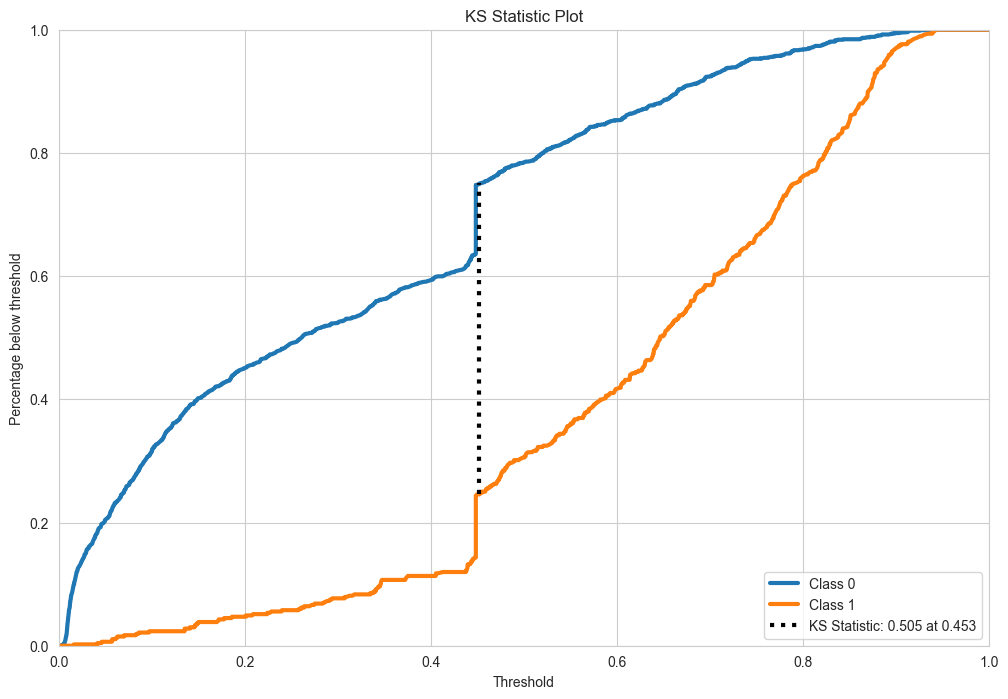

In [ ]:
print('KS plot exibido acima.')

### 4.2 Confusion matrix

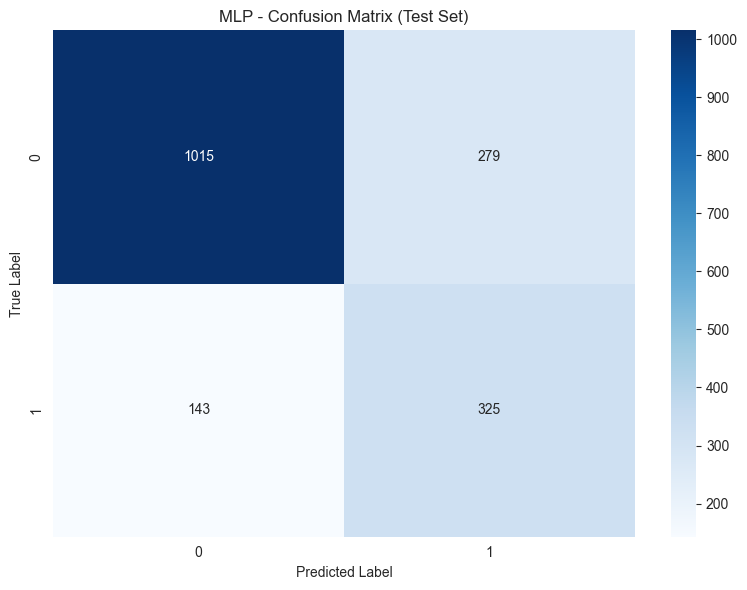

In [ ]:
print('Confusion matrix exibida acima.')

### 4.3 Arquivo final

In [ ]:
print(f'Resultados finais salvos em: {final_path}')


--- RESUMO FINAL MLP ---
Score da busca: 0.476411
KS Statistic Teste: 0.5047
AUC-ROC Teste: 0.8292
F1-Score Teste: 0.6063
Acurácia Teste: 0.7605
Precisão Teste: 0.5381
Recall Teste: 0.6944
Resultados salvos em: results/
Arquivo final: results\mlp_final_results.json

Avaliação do MLP concluída com sucesso!
